In [14]:

# -------------- SECTION 1 - IMPORTS -----------

import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.preprocessing import LabelEncoder, StandardScaler
    
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score




In [15]:
# -------------- SECTION 2 - LOAD THE DATASET -----------

#load the dataset
df = pd.read_csv("./train.csv")
    


In [16]:
# -------------- SECTION 3 - DATA PREPROCESSING -----------

# perfrom data preprocessing
# steps: handle missing values -> drop irrelevant columns -> encode categorical -> standardize

# ---- 3a. Handle missing values ----
# numeric columns: fill with median because median is not affected by outliers like mean
num_cols = df.select_dtypes(include=["number"]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# categorical columns: fill with mode (most frequent value) , appers most number of times
cat_cols = df.select_dtypes(include=["string", "object"]).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after filling:\n", df.isnull().sum()) #no values

# ---- 3b. Drop irrelevant columns ----
# Customer ID and Name are just unique ids they dont help predict anything so we drop them and they don't contruibute to the predication
df = df.drop(columns=["Customer ID", "Name"])

# drop rows where target value is missing because we cant train on empty targets
TARGET = "Loan Sanction Amount (USD)"
df = df.dropna(subset=[TARGET]) # subset = Drop rows where Loan Sanction Amount (USD) is missing.

# # ---- 3c. Encode categorical variables ----
# # LabelEncoder converts text labels into numbers like Low=0 Medium=1 High=2
# # we use is_string_dtype because in newer pandas versions str dtype is not == "object"
# encoder = LabelEncoder()
# for column in df.columns:
#     if pd.api.types.is_string_dtype(df[column]):
#         df[column] = encoder.fit_transform(df[column])

# X = df.drop(TARGET, axis=1)
# y = df[TARGET]
# feature_names = X.


# ---- 3c. Encode categorical variables ----
encoder = LabelEncoder()

for column in df.select_dtypes(include=["object"]).columns:
    df[column] = encoder.fit_transform(df[column])

X = df.drop(TARGET, axis=1)
y = df[TARGET]
feature_names = X.columns

# ---- 3d. Standardize numerical features ----
scaler = StandardScaler()
X = scaler.fit_transform(X)




Missing values after filling:
 Customer ID                    0
Name                           0
Gender                         0
Age                            0
Income (USD)                   0
Income Stability               0
Profession                     0
Type of Employment             0
Location                       0
Loan Amount Request (USD)      0
Current Loan Expenses (USD)    0
Expense Type 1                 0
Expense Type 2                 0
Dependents                     0
Credit Score                   0
No. of Defaults                0
Has Active Credit Card         0
Property ID                    0
Property Age                   0
Property Type                  0
Property Location              0
Co-Applicant                   0
Property Price                 0
Loan Sanction Amount (USD)     0
dtype: int64


C:\Users\srik2\AppData\Local\Temp\ipykernel_18160\615189513.py:42: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column in df.select_dtypes(include=["object"]).columns:


In [17]:
# -------------- SECTION 4 - EXPLORATORY DATA ANALYSIS (EDA) -----------

# Exploratory Data Analysis
# understanding the data before building models
# we check the structure, spread, and look for patterns
print("========== EDA ==========")

print("summary statistics")
print(df.describe())   # - shows count, mean, min, max, quartiles for each numeric column

print("\nfirst 5 rows")
print(df.head())       # - peek at the actual data values

print("\ninfo about dataset")
print(df.info())       # - shows column names, dtypes, non-null counts

print("\nshape of dataset")
print(df.shape)        # - shows (rows, columns). 




========== EDA ==========
summary statistics
             Gender           Age  Income (USD)  Income Stability  \
count  30000.000000  30000.000000  3.000000e+04      30000.000000   
mean       0.503533     40.092300  2.568320e+03          0.914467   
std        0.499996     16.045129  1.036924e+04          0.279678   
min        0.000000     18.000000  3.777000e+02          0.000000   
25%        0.000000     25.000000  1.743305e+03          1.000000   
50%        1.000000     40.000000  2.222435e+03          1.000000   
75%        1.000000     55.000000  2.869142e+03          1.000000   
max        1.000000     65.000000  1.777460e+06          1.000000   

         Profession  Type of Employment      Location  \
count  30000.000000        30000.000000  30000.000000   
mean       4.804900            7.892067      0.925367   
std        2.628992            3.892110      0.525045   
min        0.000000            0.000000      0.000000   
25%        1.000000            6.000000      1.0

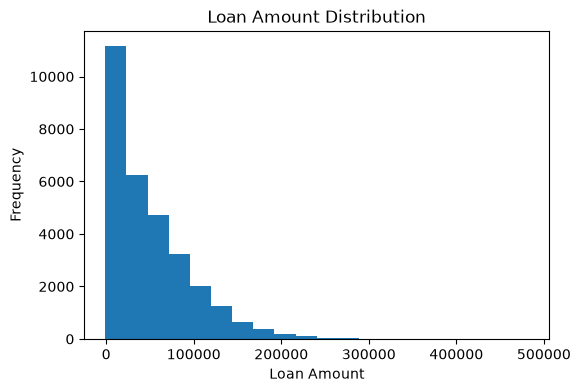

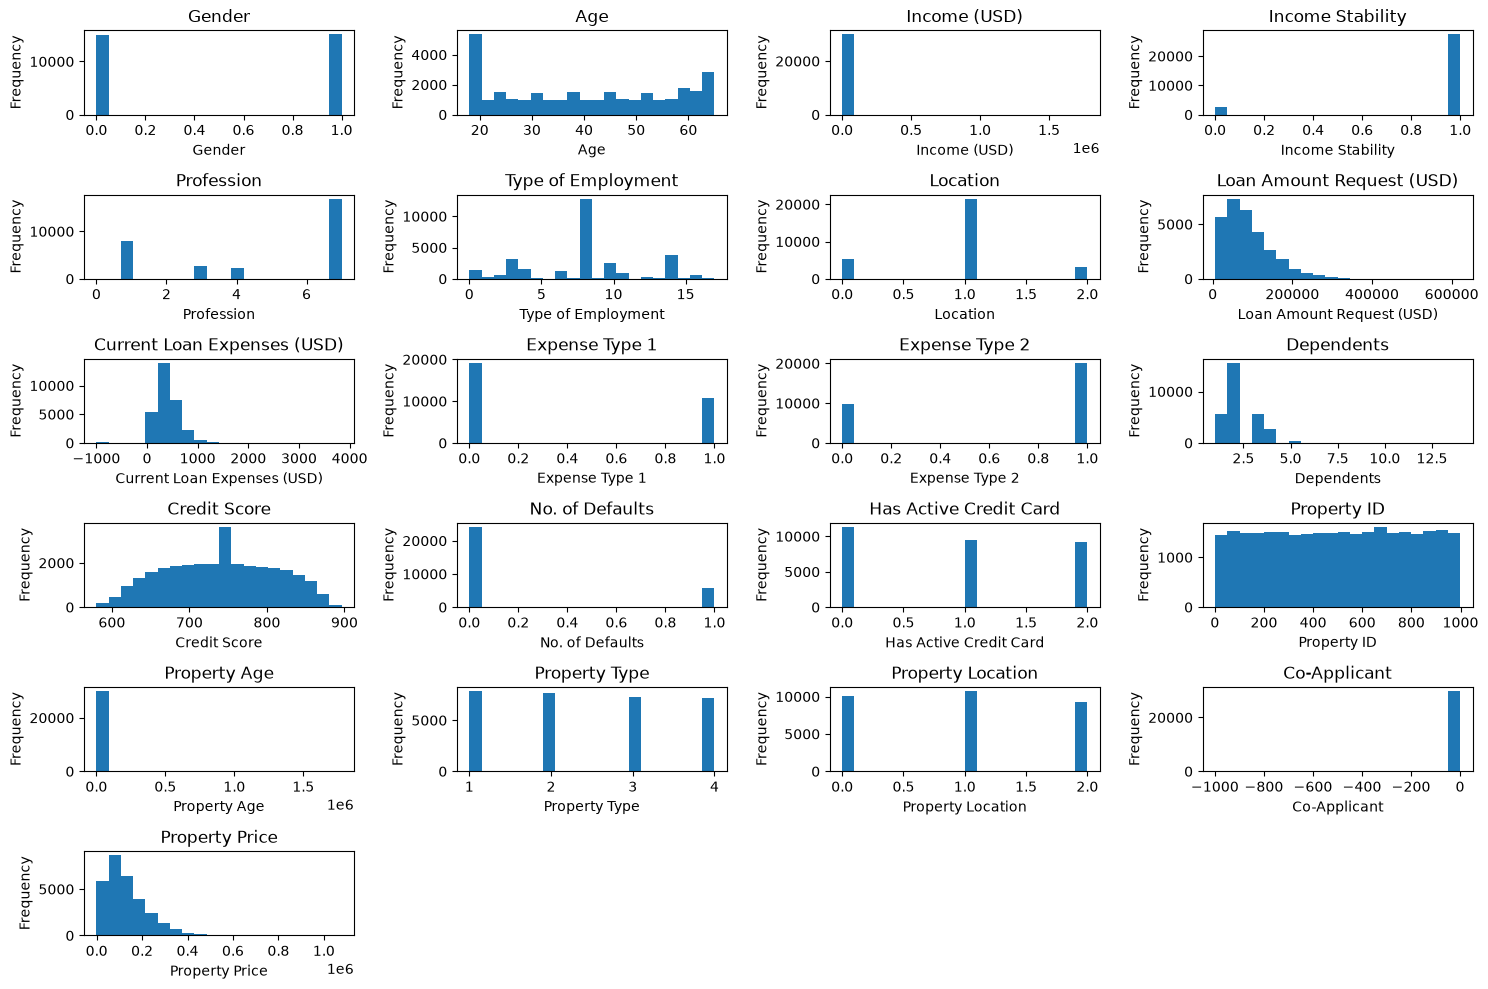

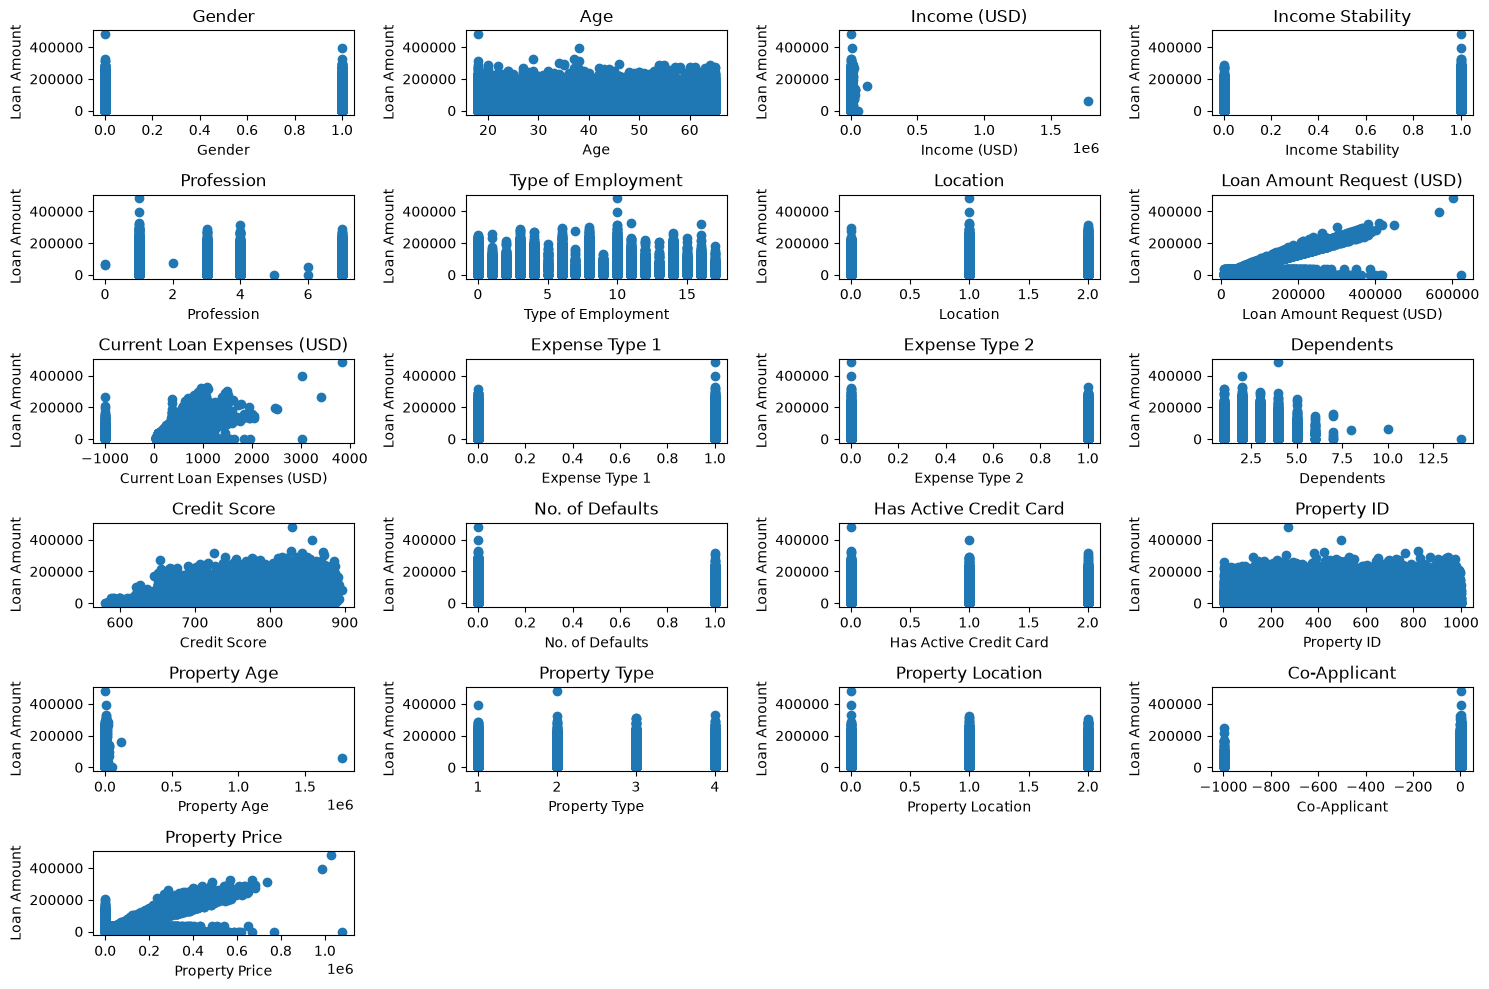

In [18]:
# -------------- SECTION 5 - VISUALIZE FEATURE DISTRIBUTIONS AND TARGET DISTRIBUTION -----------

# Visualize feature distributions and target distribution

#using the histogram
# A histogram shows how the data is distributed across different ranges
plt.figure(figsize=(6, 4))
plt.hist(y, bins=20) # bins = number of groups we split the data into like 0-20, 20-40 etc
plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")
plt.show()


# calculate rows needed for subplot grid (21 features, 4 columns = 6 rows)
grid_rows = int(np.ceil(len(feature_names) / 4))

# Feature distribution plots
# plotting histogram for each feature to see how values are spread
plt.figure(figsize=(15, 10))
  
for i, column in enumerate(feature_names, 1):
    plt.subplot(grid_rows, 4, i)   # grid_rows rows, 4 columns
    plt.hist(df[column], bins=20)
    plt.title(column)
    plt.xlabel(column)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# Feature vs Target scatter plots

# What is a Scatter Plot?
# A scatter plot shows the relationship between two numerical variables
# X-axis -> Feature (like Income, Age)
# Y-axis -> Target variable (Loan Amount)
# each dot represents one customer row
plt.figure(figsize=(15, 10))
for i, column in enumerate(feature_names, 1):
    plt.subplot(grid_rows, 4, i)
    plt.scatter(df[column], y)
    plt.title(column)
    plt.xlabel(column)
    plt.ylabel("Loan Amount")

plt.tight_layout()
plt.show()




In [19]:
# -------------- SECTION 6 - SPLIT INTO TRAINING / VALIDATION / TESTING SETS -----------

# Split the dataset into training, validation and testing sets ----------
# strategy: 70% train, 15% validation, 15% test
# first we take 30% out as temp then split that 50/50 into validation and test

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42 # random_state = seed value for the randomizer so we get same split everytime
)
# now X_temp has 30% of the data, X_train has 70%

X_validation, X_test, y_validation, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)
# now X_validation gets half of temp (15% of total) and X_test gets the other half (15% of total)




In [20]:
# -------------- SECTION 7 - METRICS HELPER (MAE, MSE, RMSE, R2) -----------

# Helper: compute MAE, MSE, RMSE, R2 in one call
# y_true contains the actual values
# y_pred contains the predicted values from the model
def calc_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred) # actual - predicted = error then take average of these errors
    mse = mean_squared_error(y_true, y_pred) # square the errors useful for catching big errors
    rmse = np.sqrt(mse) # root of the mse so its back to original unit
    r2 = r2_score(y_true, y_pred)  # tells the variation ie how much actual values differ from one another
    return mae, mse, rmse, r2




In [21]:
# -------------- SECTION 8 - NOTES ON THE FOUR MODELS -----------

# Linear Regression tries to use all features.
# Ridge Regression keeps all features but shrinks their coefficients. Less important features have smaller influence on the prediction.
# Lasso Regression: if it don't help predict the loan amount. It removes them.
# Elastic Net Regression combines both advantages of Ridge and Lasso:
                # Ridge → Keeps all features but reduces their importance.
                # Lasso → Can completely remove unimportant features.
                # Elastic Net → Does both




In [22]:
# -------------- SECTION 9 - BASELINE LINEAR REGRESSION -----------

# 6. Baseline Linear Regression
print("--------------- Linear Regression ---------------")
# equation = y = mx + c
# used whenever the output is a number (regression problem)

linear_model = LinearRegression()
start = time.time()
linear_model.fit(X_train, y_train) # The fit() method trains the model on the training data
linear_time = time.time() - start

# Predict using validation and test data
validation_prediction = linear_model.predict(X_validation)
test_prediction = linear_model.predict(X_test)

# Calculate validation metrics
val_mae, val_mse, val_rmse, val_r2 = calc_metrics(y_validation, validation_prediction) # y_validation = actual value

# Calculate test metrics
test_mae, test_mse, test_rmse, test_r2 = calc_metrics(y_test, test_prediction)

print("Validation -> MAE:", val_mae, "MSE:", val_mse, "RMSE:", val_rmse, "R2:", val_r2)
print("Test       -> MAE:", test_mae, "MSE:", test_mse, "RMSE:", test_rmse, "R2:", test_r2)




--------------- Linear Regression ---------------
Validation -> MAE: 21581.138317973906 MSE: 946162885.1445738 RMSE: 30759.760810912914 R2: 0.5822908457041305
Test       -> MAE: 22019.03138119801 MSE: 1058997847.5061067 RMSE: 32542.247118263156 R2: 0.5304430356254229


In [23]:
# -------------- SECTION 10 - RIDGE REGRESSION (GRID SEARCH, 5-FOLD CV) -----------

# 7. Ridge Regression
# adds penalty if the model tries to learn by memorizing
# alpha is the penalty here and we don't know which alpha is best so we try a bunch of alpha values

ridge_model = Ridge()

parameters = {"alpha": [0.01, 0.1, 1, 10, 100]} # creating dict containing all the alpha values to test

grid_ridge = GridSearchCV(ridge_model, parameters, cv=5) # ridge model = model to train on, parameters = values to test, cv=5 = 5-fold cross validation
start = time.time()
grid_ridge.fit(X_train, y_train)

ridge_time = time.time() - start

print("Best Parameters:", grid_ridge.best_params_)
print("Best Cross Validation R2:", grid_ridge.best_score_)

val_pred_ridge = grid_ridge.predict(X_validation)
test_pred_ridge = grid_ridge.predict(X_test)

ridge_val_mae, ridge_val_mse, ridge_val_rmse, ridge_val_r2 = calc_metrics(y_validation, val_pred_ridge)
ridge_mae, ridge_mse, ridge_rmse, ridge_r2 = calc_metrics(y_test, test_pred_ridge)

print("Validation -> MAE:", ridge_val_mae, "MSE:", ridge_val_mse, "RMSE:", ridge_val_rmse, "R2:", ridge_val_r2)
print("Test       -> MAE:", ridge_mae, "MSE:", ridge_mse, "RMSE:", ridge_rmse, "R2:", ridge_r2)




Best Parameters: {'alpha': 0.01}
Best Cross Validation R2: 0.5755124050120636
Validation -> MAE: 21581.063225180875 MSE: 946161244.9867135 RMSE: 30759.734150130647 R2: 0.5822915697961061
Test       -> MAE: 22018.99837976954 MSE: 1058970652.9352847 RMSE: 32541.8292807163 R2: 0.5304550936292732


In [24]:
# -------------- SECTION 11 - LASSO REGRESSION (GRID SEARCH, 5-FOLD CV) -----------

# 8. Lasso Regression
print("--------------- Lasso Regression ---------------")
# uses regularized model just like Ridge
# but it can completely remove unimportant features from the model
# good when the features are unnecessary

lasso = Lasso(max_iter=10000, tol=1e-3) # max_iter = max times it tries to converge, tol = when to stop early if close enough
lasso_params = {"alpha": [0.001, 0.01, 0.1, 1, 10]} # different alpha values to try

grid_lasso = GridSearchCV(lasso, lasso_params, cv=5, n_jobs=-1)
start = time.time()
grid_lasso.fit(X_train, y_train)
lasso_time = time.time() - start


print("Best Parameters :", grid_lasso.best_params_)
print("Best CV R2      :", grid_lasso.best_score_)

val_pred_lasso = grid_lasso.predict(X_validation)
test_pred_lasso = grid_lasso.predict(X_test)

lasso_val_mae, lasso_val_mse, lasso_val_rmse, lasso_val_r2 = calc_metrics(y_validation, val_pred_lasso)
lasso_mae, lasso_mse, lasso_rmse, lasso_r2 = calc_metrics(y_test, test_pred_lasso)

print("Validation -> MAE:", lasso_val_mae, "MSE:", lasso_val_mse, "RMSE:", lasso_val_rmse, "R2:", lasso_val_r2)
print("Test       -> MAE:", lasso_mae, "MSE:", lasso_mse, "RMSE:", lasso_rmse, "R2:", lasso_r2)




--------------- Lasso Regression ---------------
Best Parameters : {'alpha': 0.001}
Best CV R2      : 0.5755124096177409
Validation -> MAE: 21581.134462554433 MSE: 946162795.7401469 RMSE: 30759.759357643663 R2: 0.5822908851741289
Test       -> MAE: 22019.02971479281 MSE: 1058996502.493286 RMSE: 32542.226452615163 R2: 0.5304436320007023


In [25]:
# -------------- SECTION 12 - ELASTIC NET REGRESSION (GRID SEARCH, 5-FOLD CV) -----------

# 9. Elastic Net Regression
# combines both lasso and ridge together to remove unnecessary features and also minimize their importance
print("--------------- Elastic Net Regression ---------------")

elastic = ElasticNet(max_iter=10000, tol=1e-3)
elastic_params = {
    "alpha": [0.01, 0.1, 1, 10],
    "l1_ratio": [0.2, 0.5, 0.8] # how much ridge vs lasso to mix. 3 values because we don't know which mix is best
}

grid_elastic = GridSearchCV(elastic, elastic_params, cv=5, n_jobs=-1)
start = time.time()
grid_elastic.fit(X_train, y_train)
elastic_time = time.time() - start

print("Best Parameters :", grid_elastic.best_params_)
print("Best CV R2      :", grid_elastic.best_score_)

val_pred_elastic = grid_elastic.predict(X_validation)
test_pred_elastic = grid_elastic.predict(X_test)

elastic_val_mae, elastic_val_mse, elastic_val_rmse, elastic_val_r2 = calc_metrics(y_validation, val_pred_elastic)
elastic_mae, elastic_mse, elastic_rmse, elastic_r2 = calc_metrics(y_test, test_pred_elastic)

print("Validation -> MAE:", elastic_val_mae, "MSE:", elastic_val_mse, "RMSE:", elastic_val_rmse, "R2:", elastic_val_r2)
print("Test       -> MAE:", elastic_mae, "MSE:", elastic_mse, "RMSE:", elastic_rmse, "R2:", elastic_r2)




--------------- Elastic Net Regression ---------------
Best Parameters : {'alpha': 0.01, 'l1_ratio': 0.8}
Best CV R2      : 0.5754040254266624
Validation -> MAE: 21591.015082673694 MSE: 946431022.6561815 RMSE: 30764.11907817582 R2: 0.5821724691592807
Test       -> MAE: 22016.82550432945 MSE: 1044239533.1370833 RMSE: 32314.695312459364 R2: 0.5369868348510058


In [26]:
# -------------- SECTION 13 - NOTES ON HYPERPARAMETERS AND CROSS VALIDATION -----------

# hyperparameter is a value we set before training like alpha the model doesn't know we give it
# 5 fold or 5cv is the process of splitting the dataset into 5 sets and using 4 sets for training and the last set for validation




In [27]:
# -------------- SECTION 14 - TABLE 1 : HYPERPARAMETER TUNING SUMMARY -----------

# table 1 shows which alpha / l1_ratio combo gave the best cv score for each regularized model
table1 = pd.DataFrame({
    "Model": ["Ridge Regression", "Lasso Regression", "Elastic Net Regression"],
    "Search Method": ["Grid Search", "Grid Search", "Grid Search"],
    "Best Parameters": [grid_ridge.best_params_, grid_lasso.best_params_, grid_elastic.best_params_],
    "Best Cross Validation R2": [grid_ridge.best_score_, grid_lasso.best_score_, grid_elastic.best_score_]
})
print("\nTable 1: Hyperparameter Tuning Summary")
print(table1)





Table 1: Hyperparameter Tuning Summary
                    Model Search Method                   Best Parameters  \
0        Ridge Regression   Grid Search                   {'alpha': 0.01}   
1        Lasso Regression   Grid Search                  {'alpha': 0.001}   
2  Elastic Net Regression   Grid Search  {'alpha': 0.01, 'l1_ratio': 0.8}   

   Best Cross Validation R2  
0                  0.575512  
1                  0.575512  
2                  0.575404  


In [28]:
# -------------- SECTION 15 - TABLE 2 : VALIDATION PERFORMANCE SUMMARY -----------

# table 2 uses the validation set (the data we used to pick the best model)
table2 = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression", "Lasso Regression", "Elastic Net"],
    "MAE": [val_mae, ridge_val_mae, lasso_val_mae, elastic_val_mae],
    "MSE": [val_mse, ridge_val_mse, lasso_val_mse, elastic_val_mse],
    "RMSE": [val_rmse, ridge_val_rmse, lasso_val_rmse, elastic_val_rmse],
    "R2 Score": [val_r2, ridge_val_r2, lasso_val_r2, elastic_val_r2]
})
print("\nTable 2: Validation Performance Summary")
print(table2)





Table 2: Validation Performance Summary
               Model           MAE           MSE          RMSE  R2 Score
0  Linear Regression  21581.138318  9.461629e+08  30759.760811  0.582291
1   Ridge Regression  21581.063225  9.461612e+08  30759.734150  0.582292
2   Lasso Regression  21581.134463  9.461628e+08  30759.759358  0.582291
3        Elastic Net  21591.015083  9.464310e+08  30764.119078  0.582172


In [29]:
# -------------- SECTION 16 - TABLE 3 : TEST SET PERFORMANCE -----------

# table 3 is the final test, the model never saw this data before
table3 = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression", "Lasso Regression", "Elastic Net"],
    "MAE": [test_mae, ridge_mae, lasso_mae, elastic_mae],
    "MSE": [test_mse, ridge_mse, lasso_mse, elastic_mse],
    "RMSE": [test_rmse, ridge_rmse, lasso_rmse, elastic_rmse],
    "R2 Score": [test_r2, ridge_r2, lasso_r2, elastic_r2],
    "Training Time (s)": [linear_time, ridge_time, lasso_time, elastic_time]
})
print("\nTable 3: Test Set Performance")
print(table3)





Table 3: Test Set Performance
               Model           MAE           MSE          RMSE  R2 Score  \
0  Linear Regression  22019.031381  1.058998e+09  32542.247118  0.530443   
1   Ridge Regression  22018.998380  1.058971e+09  32541.829281  0.530455   
2   Lasso Regression  22019.029715  1.058997e+09  32542.226453  0.530444   
3        Elastic Net  22016.825504  1.044240e+09  32314.695312  0.536987   

   Training Time (s)  
0           0.030100  
1           0.646502  
2          22.615229  
3           0.900045  


In [30]:
# -------------- SECTION 17 - TABLE 4 : COEFFICIENT COMPARISON -----------

# table 4 shows how much each feature pushes the loan amount up or down for every model
table4 = pd.DataFrame({
    "Feature": feature_names,
    "Linear": linear_model.coef_,
    "Ridge": grid_ridge.best_estimator_.coef_,
    "Lasso": grid_lasso.best_estimator_.coef_,
    "Elastic Net": grid_elastic.best_estimator_.coef_
})
print("\nTable 4: Coefficient Comparison")
print(table4)





Table 4: Coefficient Comparison
                        Feature        Linear         Ridge         Lasso  \
0                        Gender   -186.533268   -186.532101   -186.532135   
1                           Age   -558.498535   -558.469892   -558.496352   
2                  Income (USD)  39992.153645  39801.132521  39982.679539   
3              Income Stability    811.510885    811.507117    811.509438   
4                    Profession    -87.335066    -87.345919    -87.334495   
5            Type of Employment    184.040186    184.044929    184.039319   
6                      Location     66.532571     66.576599     66.533999   
7     Loan Amount Request (USD)  34116.844820  34116.729556  34116.827485   
8   Current Loan Expenses (USD)   -525.759856   -525.673937   -525.753041   
9                Expense Type 1     95.794139     95.832356     95.794914   
10               Expense Type 2    400.271081    400.274481    400.270190   
11                   Dependents   -549.2902

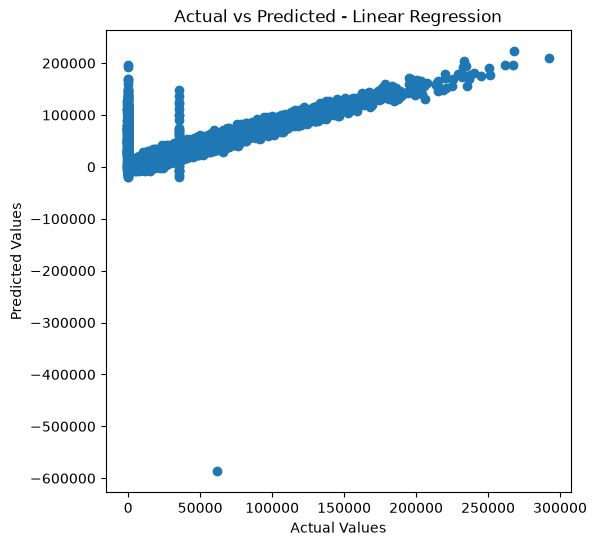

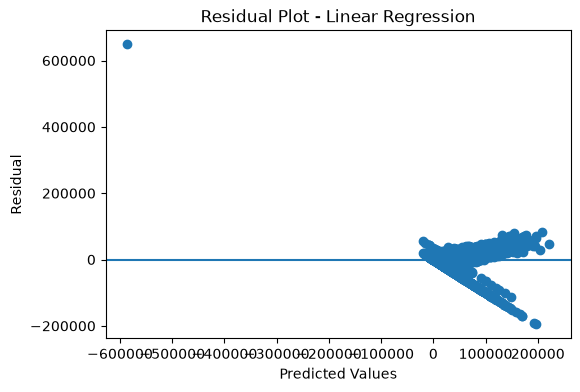

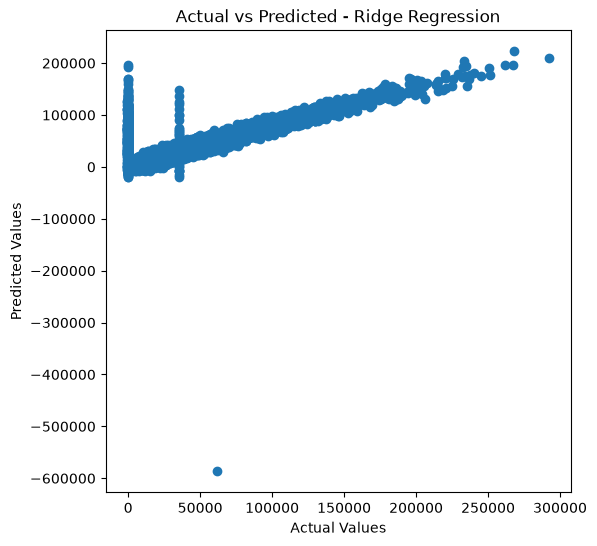

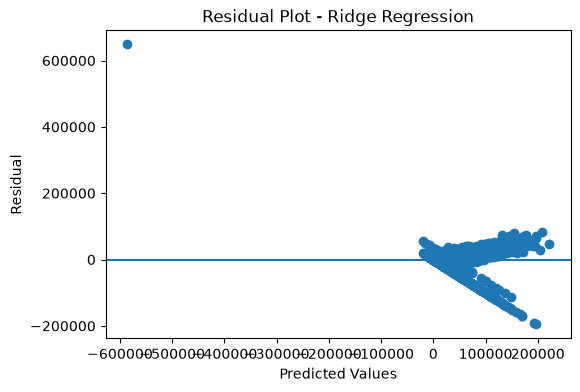

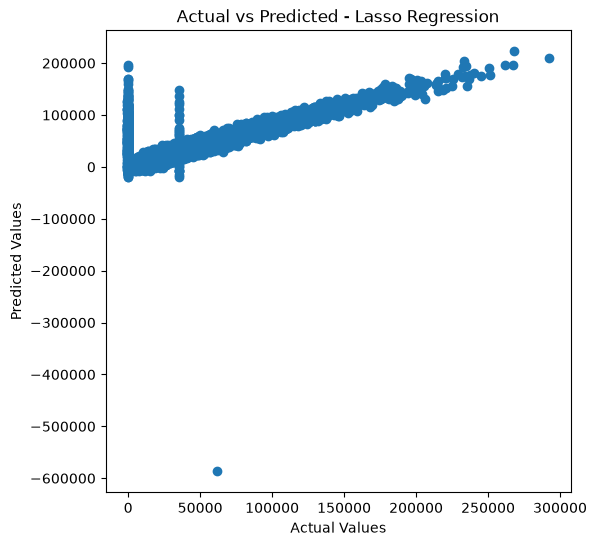

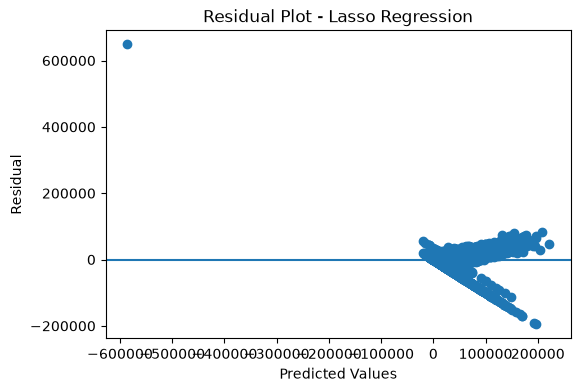

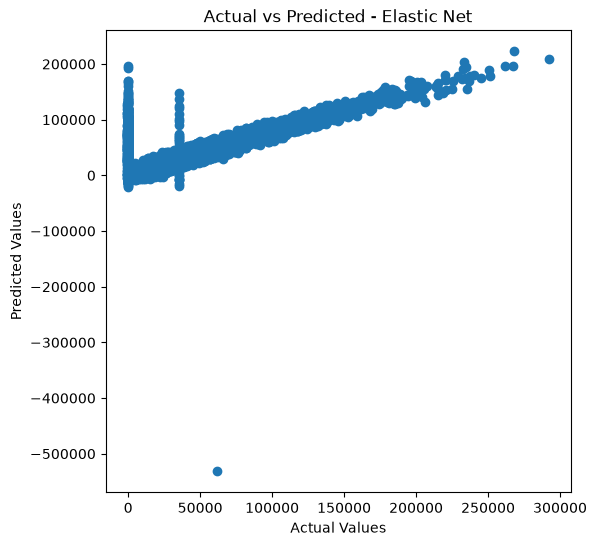

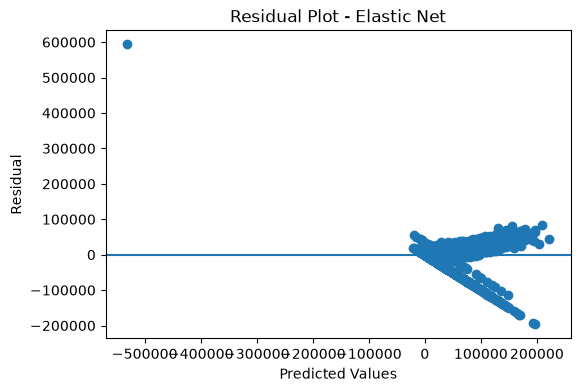

In [31]:
# -------------- SECTION 18 - VISUALIZATION : PREDICTED VS ACTUAL AND RESIDUAL PLOTS -----------

# 14. Visualizations - Predicted vs Actual & Residuals (all models)


#sns is built on over the matplotlib

model_preds = {    #stores model name and its predictions
    "Linear Regression": test_prediction,
    "Ridge Regression": test_pred_ridge,
    "Lasso Regression": test_pred_lasso,
    "Elastic Net": test_pred_elastic
}

for name, preds in model_preds.items():
    # Predicted vs Actual
    plt.figure(figsize=(6, 6))
    plt.scatter(y_test, preds)
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title(f"Actual vs Predicted - {name}")
    plt.show()

    # Residual plot
    #residual = actual - predicated
    # here y-test is actual and the pred is predicted
    residual = y_test - preds
    plt.figure(figsize=(6, 4))
    plt.scatter(preds, residual)
    plt.axhline(y=0)
    plt.xlabel("Predicted Values")
    plt.ylabel("Residual")
    plt.title(f"Residual Plot - {name}")
    plt.show()




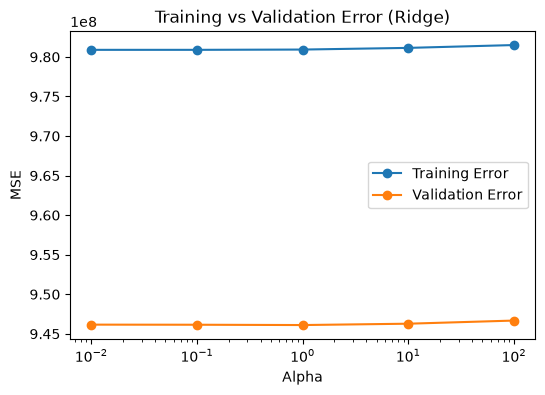

In [32]:
# -------------- SECTION 19 - VISUALIZATION : TRAINING VS VALIDATION ERROR ACROSS RIDGE ALPHAS -----------

# 15. Training vs Validation Error across Ridge alphas
# we do this to check for overfitting and underfitting

# create two empty lists to store train and validation error
train_error = []
validation_error = []
alphas = [0.01, 0.1, 1, 10, 100] # range of alphas to test

for alpha in alphas:
    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)
    train_prediction = model.predict(X_train)
    validation_prediction = model.predict(X_validation)

    # mean_squared_error is a function from sklearn
    train_error.append(mean_squared_error(y_train, train_prediction))
    validation_error.append(mean_squared_error(y_validation, validation_prediction))


plt.figure(figsize=(6, 4))
plt.plot(alphas, train_error, marker="o", label="Training Error")
plt.plot(alphas, validation_error, marker="o", label="Validation Error")
plt.xscale("log") # why log is because each value is 10times its previous one
plt.xlabel("Alpha")
plt.ylabel("MSE")
plt.title("Training vs Validation Error (Ridge)")
plt.legend()
plt.show()




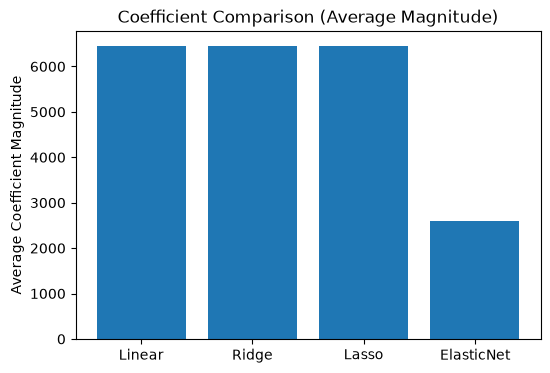

In [33]:
# -------------- SECTION 20 - VISUALIZATION : COEFFICIENT COMPARISON BAR PLOT -----------

# 16. Coefficient Comparison Bar Plot (average magnitude)

# Suppose your model is

# Loan Amount =
# 5000
# + 120 × Income
# + 80 × Credit Score
# − 30 × Age
# Then the coefficients are 120,80,30

# Linear Regression → Uses the original coefficients.
# Ridge Regression → Shrinks coefficients slightly.
# Lasso Regression → Shrinks some coefficients to zero (feature selection).
# Elastic Net → Combination of Ridge and Lasso.

#this graph is used to know how each model is compressed coefficents

models_list = ["Linear", "Ridge", "Lasso", "ElasticNet"]
coefficients = [
    # np.abs = absolute value so negative values become positive
    # best_estimator_ returns the best model from grid search
    # .coef_ gives the coefficients of that model
    np.mean(np.abs(linear_model.coef_)),
    np.mean(np.abs(grid_ridge.best_estimator_.coef_)),
    np.mean(np.abs(grid_lasso.best_estimator_.coef_)),
    np.mean(np.abs(grid_elastic.best_estimator_.coef_))
]

plt.figure(figsize=(6, 4))
plt.bar(models_list, coefficients)
plt.title("Coefficient Comparison (Average Magnitude)")
plt.ylabel("Average Coefficient Magnitude")
plt.show()




In [34]:
# -------------- SECTION 21 - TABLE 5 : TRAINING VS VALIDATION MSE (OVERFITTING / UNDERFITTING) -----------

# table 5 compares train and val mse; if train is way lower the model is memorizing (overfitting)
train_pred_linear = linear_model.predict(X_train)
train_pred_ridge = grid_ridge.predict(X_train)
train_pred_lasso = grid_lasso.predict(X_train)
train_pred_elastic = grid_elastic.predict(X_train)

train_mse_linear = mean_squared_error(y_train, train_pred_linear)
train_mse_ridge = mean_squared_error(y_train, train_pred_ridge)
train_mse_lasso = mean_squared_error(y_train, train_pred_lasso)
train_mse_elastic = mean_squared_error(y_train, train_pred_elastic)

table5 = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression", "Lasso Regression", "Elastic Net"],
    "Training MSE": [train_mse_linear, train_mse_ridge, train_mse_lasso, train_mse_elastic],
    "Validation MSE": [val_mse, ridge_val_mse, lasso_val_mse, elastic_val_mse],
    "Gap (Val - Train)": [
        val_mse - train_mse_linear,
        ridge_val_mse - train_mse_ridge,
        lasso_val_mse - train_mse_lasso,
        elastic_val_mse - train_mse_elastic
    ]
})
print("\nTable 5: Training vs Validation MSE (use this for the Overfitting/Underfitting write-up)")
print(table5)

# done - all tables and plots generated
print("\nAll tables generated: table1, table2, table3, table4, table5")



Table 5: Training vs Validation MSE (use this for the Overfitting/Underfitting write-up)
               Model  Training MSE  Validation MSE  Gap (Val - Train)
0  Linear Regression  9.808930e+08    9.461629e+08      -3.473008e+07
1   Ridge Regression  9.808930e+08    9.461612e+08      -3.473173e+07
2   Lasso Regression  9.808930e+08    9.461628e+08      -3.473017e+07
3        Elastic Net  9.812713e+08    9.464310e+08      -3.484028e+07

All tables generated: table1, table2, table3, table4, table5
